# Proposal

Measure and compare the vocabulary distributions and high-frequency words across two separate works by the same author.

Compare the word frequency distribution of those works against a work by a different author to identify unique vocabulary signatures.

Primary Author: Arthur Conan Doyle

Book 1: A Study in Scarlet
https://www.gutenberg.org/cache/epub/244/pg244.txt

Book 2: The Sign of the Four
https://www.gutenberg.org/cache/epub/2097/pg2097.txt

Secondary Author: Robert Louis Stevenson

Book 1: Treasure Island
https://www.gutenberg.org/cache/epub/120/pg120.txt

I plan to use NLTK and BeautifulSoup libraries to ingest, process and analyze the data.
I would use Matplotlib to visualize results

# Data Processing

In [1]:
import re
import requests
import nltk
from bs4 import BeautifulSoup
from collections import Counter
import matplotlib.pyplot as plt

# 1. Setup stopwords
nltk.download('stopwords', quiet=True)
stop_words = set(nltk.corpus.stopwords.words('english'))
stop_words.update({'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'', '\"', '-', '}', '{', '&', '|', u'\u2014' })

def clean_html(html_content):
    """Strip HTML/metadata tags if present."""
    soup = BeautifulSoup(html_content, 'html.parser')
    return soup.get_text()


def strip_gutenberg_headers(text):
    """Extract only the main story text between Gutenberg start/end markers."""
    start_match = re.search(r'\*\*\*\s*START OF (THE|THIS) PROJECT GUTENBERG', text, re.IGNORECASE)
    end_match = re.search(r'\*\*\*\s*END OF (THE|THIS) PROJECT GUTENBERG', text, re.IGNORECASE)
    
    start_idx = start_match.end() if start_match else 0
    end_idx = end_match.start() if end_match else len(text)
    
    return text[start_idx:end_idx]


def get_word_frequencies(url, top_n=15):
    """Fetch text, clean, tokenize, remove stopwords, and return top frequencies."""
    response = requests.get(url)
    raw_text = clean_html(response.text)
    story_text = strip_gutenberg_headers(raw_text).lower()

    # Regex to select words of >= 2 chars and skipping punctuation, quotes (“/”), and numbers
    words = re.findall(r'\b[a-z]{2,}\b', story_text)

    # Filter stopwords and count
    filtered_words = [w for w in words if w not in stop_words]
    word_counts = Counter(filtered_words)
    total_meaningful_words = sum(word_counts.values())

    # Return ascending order so the highest frequencies appear at the top of barh
    top_frequencies = word_counts.most_common(top_n)[::-1]
    
    return top_frequencies, total_meaningful_words

# Chart Plotting Function

In [2]:
def plot_comparison(wf_left, wf_right, title_left, title_right, main_title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=False)
    fig.suptitle(main_title, fontsize=16, weight='bold')

    # Subplot 1: Book 1
    labels1, values1 = zip(*wf_left)
    y_pos1 = range(len(labels1))
    ax1.barh(y_pos1, values1, color='steelblue', align='center')
    ax1.set_yticks(y_pos1)
    ax1.set_yticklabels(labels1, fontsize=11)
    ax1.set_title(title_left, fontsize=13)
    ax1.set_xlabel('Frequency')

    # Subplot 2: Book 2
    labels2, values2 = zip(*wf_right)
    y_pos2 = range(len(labels2))
    ax2.barh(y_pos2, values2, color='coral', align='center')
    ax2.set_yticks(y_pos2)
    ax2.set_yticklabels(labels2, fontsize=11)
    ax2.set_title(title_right, fontsize=13)
    ax2.set_xlabel('Frequency')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# 1. Compare word frequencies between two works of a single author.

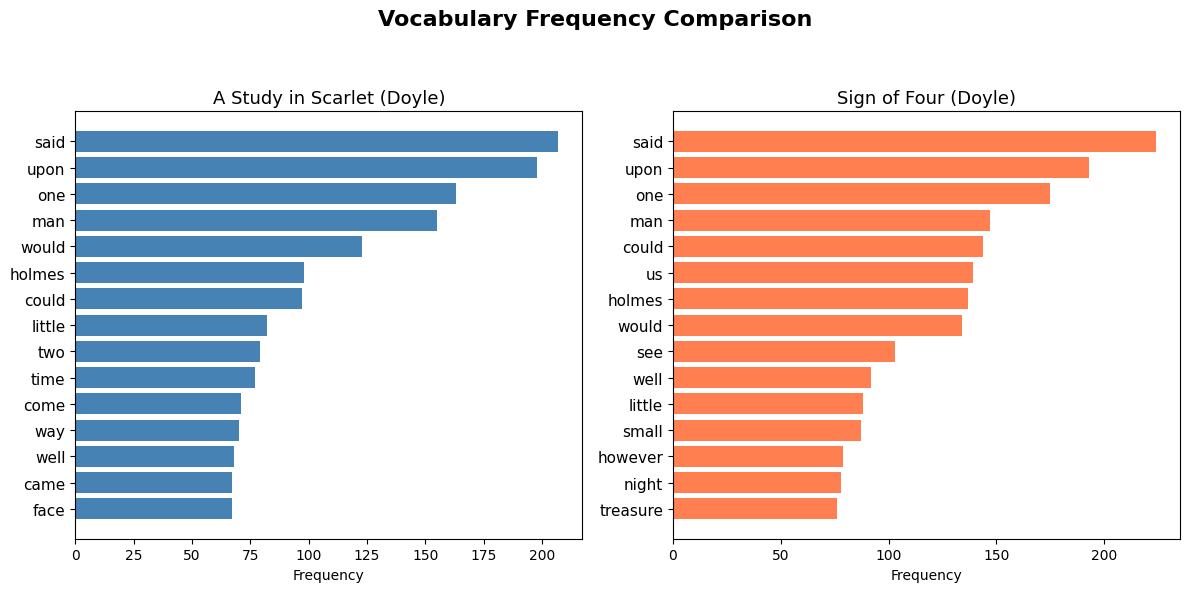

In [3]:
url_scarlet = 'https://www.gutenberg.org/cache/epub/244/pg244.txt'
url_four = 'https://www.gutenberg.org/cache/epub/2097/pg2097.txt'

wf_scarlet, total_scarlet = get_word_frequencies(url_scarlet, top_n=15)
wf_four, total_four = get_word_frequencies(url_four, top_n=15)

plot_comparison(
    wf_scarlet, 
    wf_four, 
    'A Study in Scarlet (Doyle)', 
    'Sign of Four (Doyle)', 
    'Vocabulary Frequency Comparison'
)

# 2. Compare word frequencies between works of two authors.

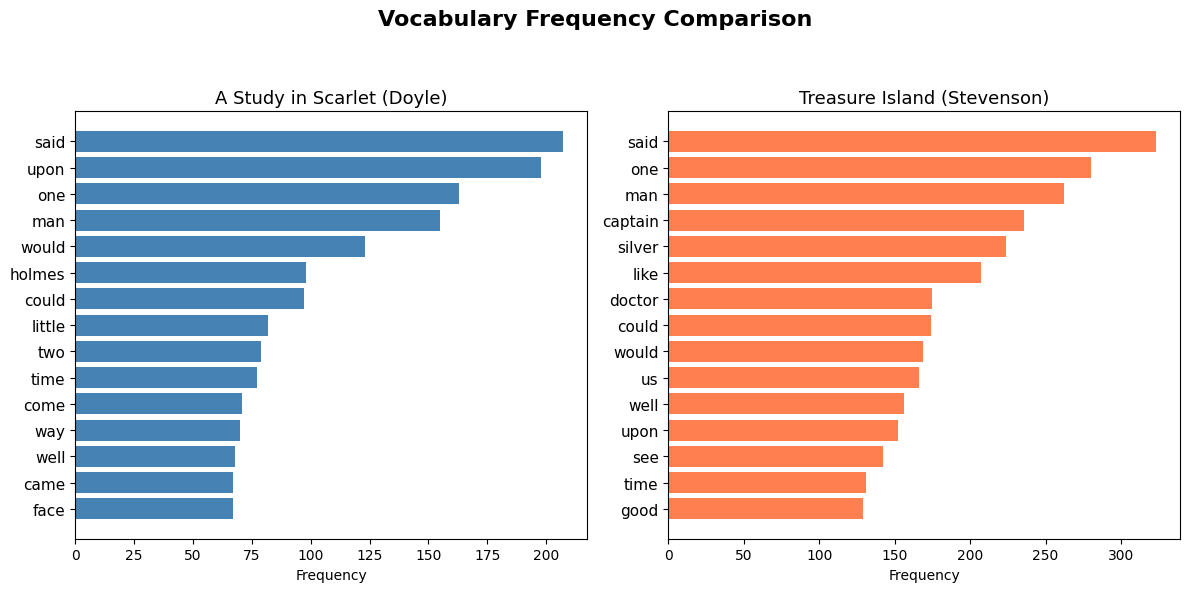

In [4]:
url_scarlet = 'https://www.gutenberg.org/cache/epub/244/pg244.txt'
url_treasure = 'https://www.gutenberg.org/cache/epub/120/pg120.txt'

wf_scarlet, total_scarlet = get_word_frequencies(url_scarlet, top_n=15)
wf_treasure, total_treasure = get_word_frequencies(url_treasure, top_n=15)

plot_comparison(
    wf_scarlet, 
    wf_treasure, 
    'A Study in Scarlet (Doyle)', 
    'Treasure Island (Stevenson)', 
    'Vocabulary Frequency Comparison'
)

# 3. Are there some words preferred by one author but used less frequently by another author?



**Vocabulary Differences**

* **Arthur Conan Doyle** shows a strong preference for detective-centered terminology, with **"holmes"** appearing as a top-frequency word across both *A Study in Scarlet* and *The Sign of the Four*. This term does not appear among the top words in Stevenson's work.


* **Robert Louis Stevenson** exhibits a preference for nautical and pirate adventure terms in *Treasure Island*, where **"captain"**, **"silver"**, and **"doctor"** rank among his most frequently used words. None of these terms reach the top tier in Doyle’s Sherlock Holmes stories.


* Stevenson shows a preference for descriptive terms like **"like"**, **"see"**, and **"us"**, all of which appear in the top 15 for *Treasure Island* but not in Doyle's top 15.


* Doyle demonstrates a stronger preference for terms such as **"little"**, **"two"**, **"way"**, and **"came"** in *A Study in Scarlet*.



**Vocabulary Similarities**

* Both authors share high usage for standard narrative dialogue and framing verbs such as **"said"**, **"one"**, **"man"**, **"upon"**, **"would"**, and **"could"**.



# Attempting extra credit 

In [5]:
import numpy as np
from scipy import stats

def test_word_binomial(k1, n1, k2, n2, label1="Book 1", label2="Book 2", word="would"):
    p1, p2 = k1 / n1, k2 / n2
    p_pool = (k1 + k2) / (n1 + n2)
    
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z_stat = (p1 - p2) / se
    p_val = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    
    print(f"--- Binomial Test for '{word}' ---")
    print(f"{label1}: p_hat = {p1:.5f} ({k1}/{n1})")
    print(f"{label2}: p_hat = {p2:.5f} ({k2}/{n2})")
    print(f"z-score: {z_stat:.3f}, p-value: {p_val:.4e}")
    print(f"Significant difference (alpha=0.05): {p_val < 0.05}\n")

In [10]:
# Convert top-15 tuples into lookup dictionaries
counts_scarlet = dict(wf_scarlet)
counts_treasure = dict(wf_treasure)
counts_four = dict(wf_four)

# --- Test 1: Between different authors for "said" ---
# Doyle (Study in Scarlet) vs. Stevenson (Treasure Island)
k_scarlet = counts_scarlet.get('said', 0)
k_treasure = counts_treasure.get('said', 0)

test_word_binomial(
    k1=k_scarlet, n1=total_scarlet,
    k2=k_treasure, n2=total_treasure,
    label1="Study in Scarlet (Doyle)",
    label2="Treasure Island (Stevenson)",
    word="said"
)

# --- Test 2: Between books by the same author for "said" ---
# Doyle (Study in Scarlet) vs. Doyle (Sign of the Four)
k_four = counts_four.get('said', 0)

test_word_binomial(
    k1=k_scarlet, n1=total_scarlet,
    k2=k_four, n2=total_four,
    label1="Study in Scarlet (Doyle)",
    label2="Sign of the Four (Doyle)",
    word="said"
)

--- Binomial Test for 'said' ---
Study in Scarlet (Doyle): p_hat = 0.01037 (207/19957)
Treasure Island (Stevenson): p_hat = 0.01007 (323/32071)
z-score: 0.332, p-value: 7.3962e-01
Significant difference (alpha=0.05): False

--- Binomial Test for 'said' ---
Study in Scarlet (Doyle): p_hat = 0.01037 (207/19957)
Sign of the Four (Doyle): p_hat = 0.01119 (224/20010)
z-score: -0.796, p-value: 4.2625e-01
Significant difference (alpha=0.05): False

